## Linear Regression implementation in scikit-learn 

In [110]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

import pandas as pd

In [111]:
# Synthetic dataset 
# fix the seed 
np.random.seed(7)
X, y = make_regression(n_samples=300, n_features=1, noise=20, random_state=7) # for single feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape, X_test.shape[0]/X_train.shape[0])


(240, 1) (60, 1) 0.25


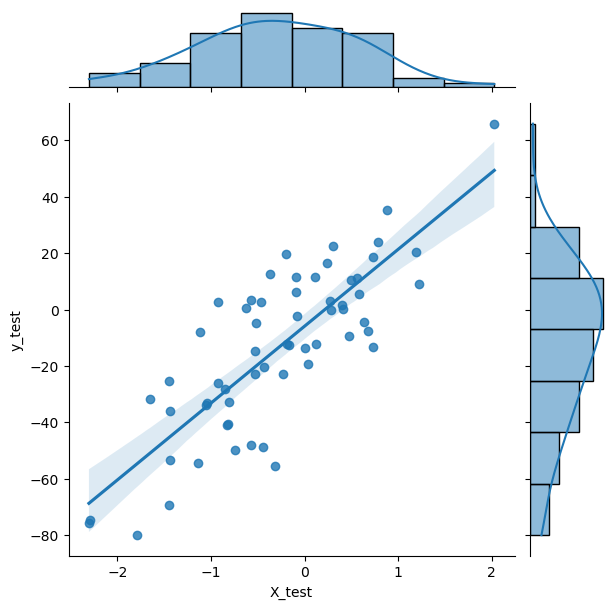

In [112]:
sns_test = sns.jointplot(x = X_test.ravel(), y=y_test.ravel(), kind='reg')

sns_test.set_axis_labels("X_test", "y_test")


In [113]:
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression().fit(X_train, y_train) # instance of Linear Regression
y_pred = lr.predict(X_test)
# Print co efficients 
slope = lr.coef_
intercept = lr.intercept_

print(f"Slope: {slope}, \n Intercept: {intercept}")

# Train and test score
print(f"Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Test set score: {lr.score(X_test, y_test):.2f}")

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(r"$R^2$" f"= {r2_score(y_test, y_pred)}")


Slope: [29.49488324], 
 Intercept: -1.1604923340894446
Training set score: 0.68
Test set score: 0.63
Mean Squared Error: 306.78530909578495
$R^2$= 0.6341552930964304


# Linear Regression from scratch

Linear regression model consists of one equation of linearly increasing variables along with a coefficient estimation algorithm 'least squares', which attempts to determine the best possible coefficients. Commonly used in forecasting, trend analysis, and predictive modelling.

The equation of a simple linear regression model is:

$$\hat{y}​=b_0 ​+ b_1 ​x $$

We can calculate the slope ($b_1$) and intercept ($b_0$) using the least-squares equations:


$$ b_1 = \frac{cov(x,y)} {var(x)} = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})} {\sum (x_i-\bar{x})^2} $$


$$ b_0 = \bar{y} -\frac{cov(x,y)} {var(x)}\bar{x} = \bar{y} - b_1 \bar{x}$$

Mean-squared error ([Scikit documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error))

If $y_i$: Actual value, $\hat{y}_i$: Predicted value, $\bar{y}$ = mean of actual values

$$
\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.
$$

$R^2$ score (**coefficient of determination**)

$$
R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
$$

Where:

Residual Sum of Squares

$$
  \text{SS}_{\text{res}} = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$



Total Sum of Squares

$$
  \text{SS}_{\text{tot}} = \sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2
$$  

- $R^2 = 1$ -> perfect predictions
- $R^2 = 0$ -> no better than predicting the mean
- $R^2 < 0$ -> worse than predicting the mean


In [114]:
class MyLinearRegression():
    def __init__(self):
        self.coeff = None
    
    def fit(self, X, y):
        self.coeff = self.calculate_b0_b1(X,y)
                
    def  calculate_b0_b1(self, X, y):
        x_mean = np.mean(X)
        y_mean = np.mean(y)

        # Calculate slope
        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)

        b1 = numerator / denominator

        # Calculate intercept
        b0 = y_mean - b1 * x_mean   
        
        return [b0, b1]
    
    def predict(self, X):
        
        y_pred = self.coeff[0] + self.coeff[1]*X
        return y_pred
        
    def MSE(self, y_test, y_pred):
        return (np.mean((y_pred - y_test)**2))
    
    def r2_score(self,y_test, y_pred):
        ss_res = np.sum((y_test - y_pred) ** 2)

        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

        r2 = 1 - (ss_res / ss_tot)    
        return r2
        

In [115]:
# # # # # # # # # # # # # # # # #
# My Linear Regression #
# # # # # # # # # # # # # # # # #
my_lr = MyLinearRegression()

# Update the shape properly to 1D array
X_train = X_train.ravel()
X_test  = X_test.ravel()

y_train = y_train.ravel()
y_test  = y_test.ravel()

# fit our LR to our data
my_lr.fit(X_train, y_train)
#coeffs
coeff = my_lr.calculate_b0_b1(X_train, y_train)
print(f"Slope: {coeff[1]}, \n Intercept: {coeff[0]}")
# make predictions and score
y_pred = my_lr.predict(X_test)

# calculate r2_score
r2score = my_lr.r2_score(y_test, y_pred)
print(f'My Final R2 score: {r2score}')

# calculate MSE 
mse = my_lr.MSE(y_test, y_pred)
print(f'My Final MSE score: {mse}')



Slope: 29.49488323993304, 
 Intercept: -1.1604923340894446
My Final R2 score: 0.6341552930964304
My Final MSE score: 306.78530909578495


## Diabetic dataset :: Example of Multiple Linear Regression

In [116]:

from sklearn import datasets
diabetes = datasets.load_diabetes()
diabetes.keys()
print(diabetes["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [117]:
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


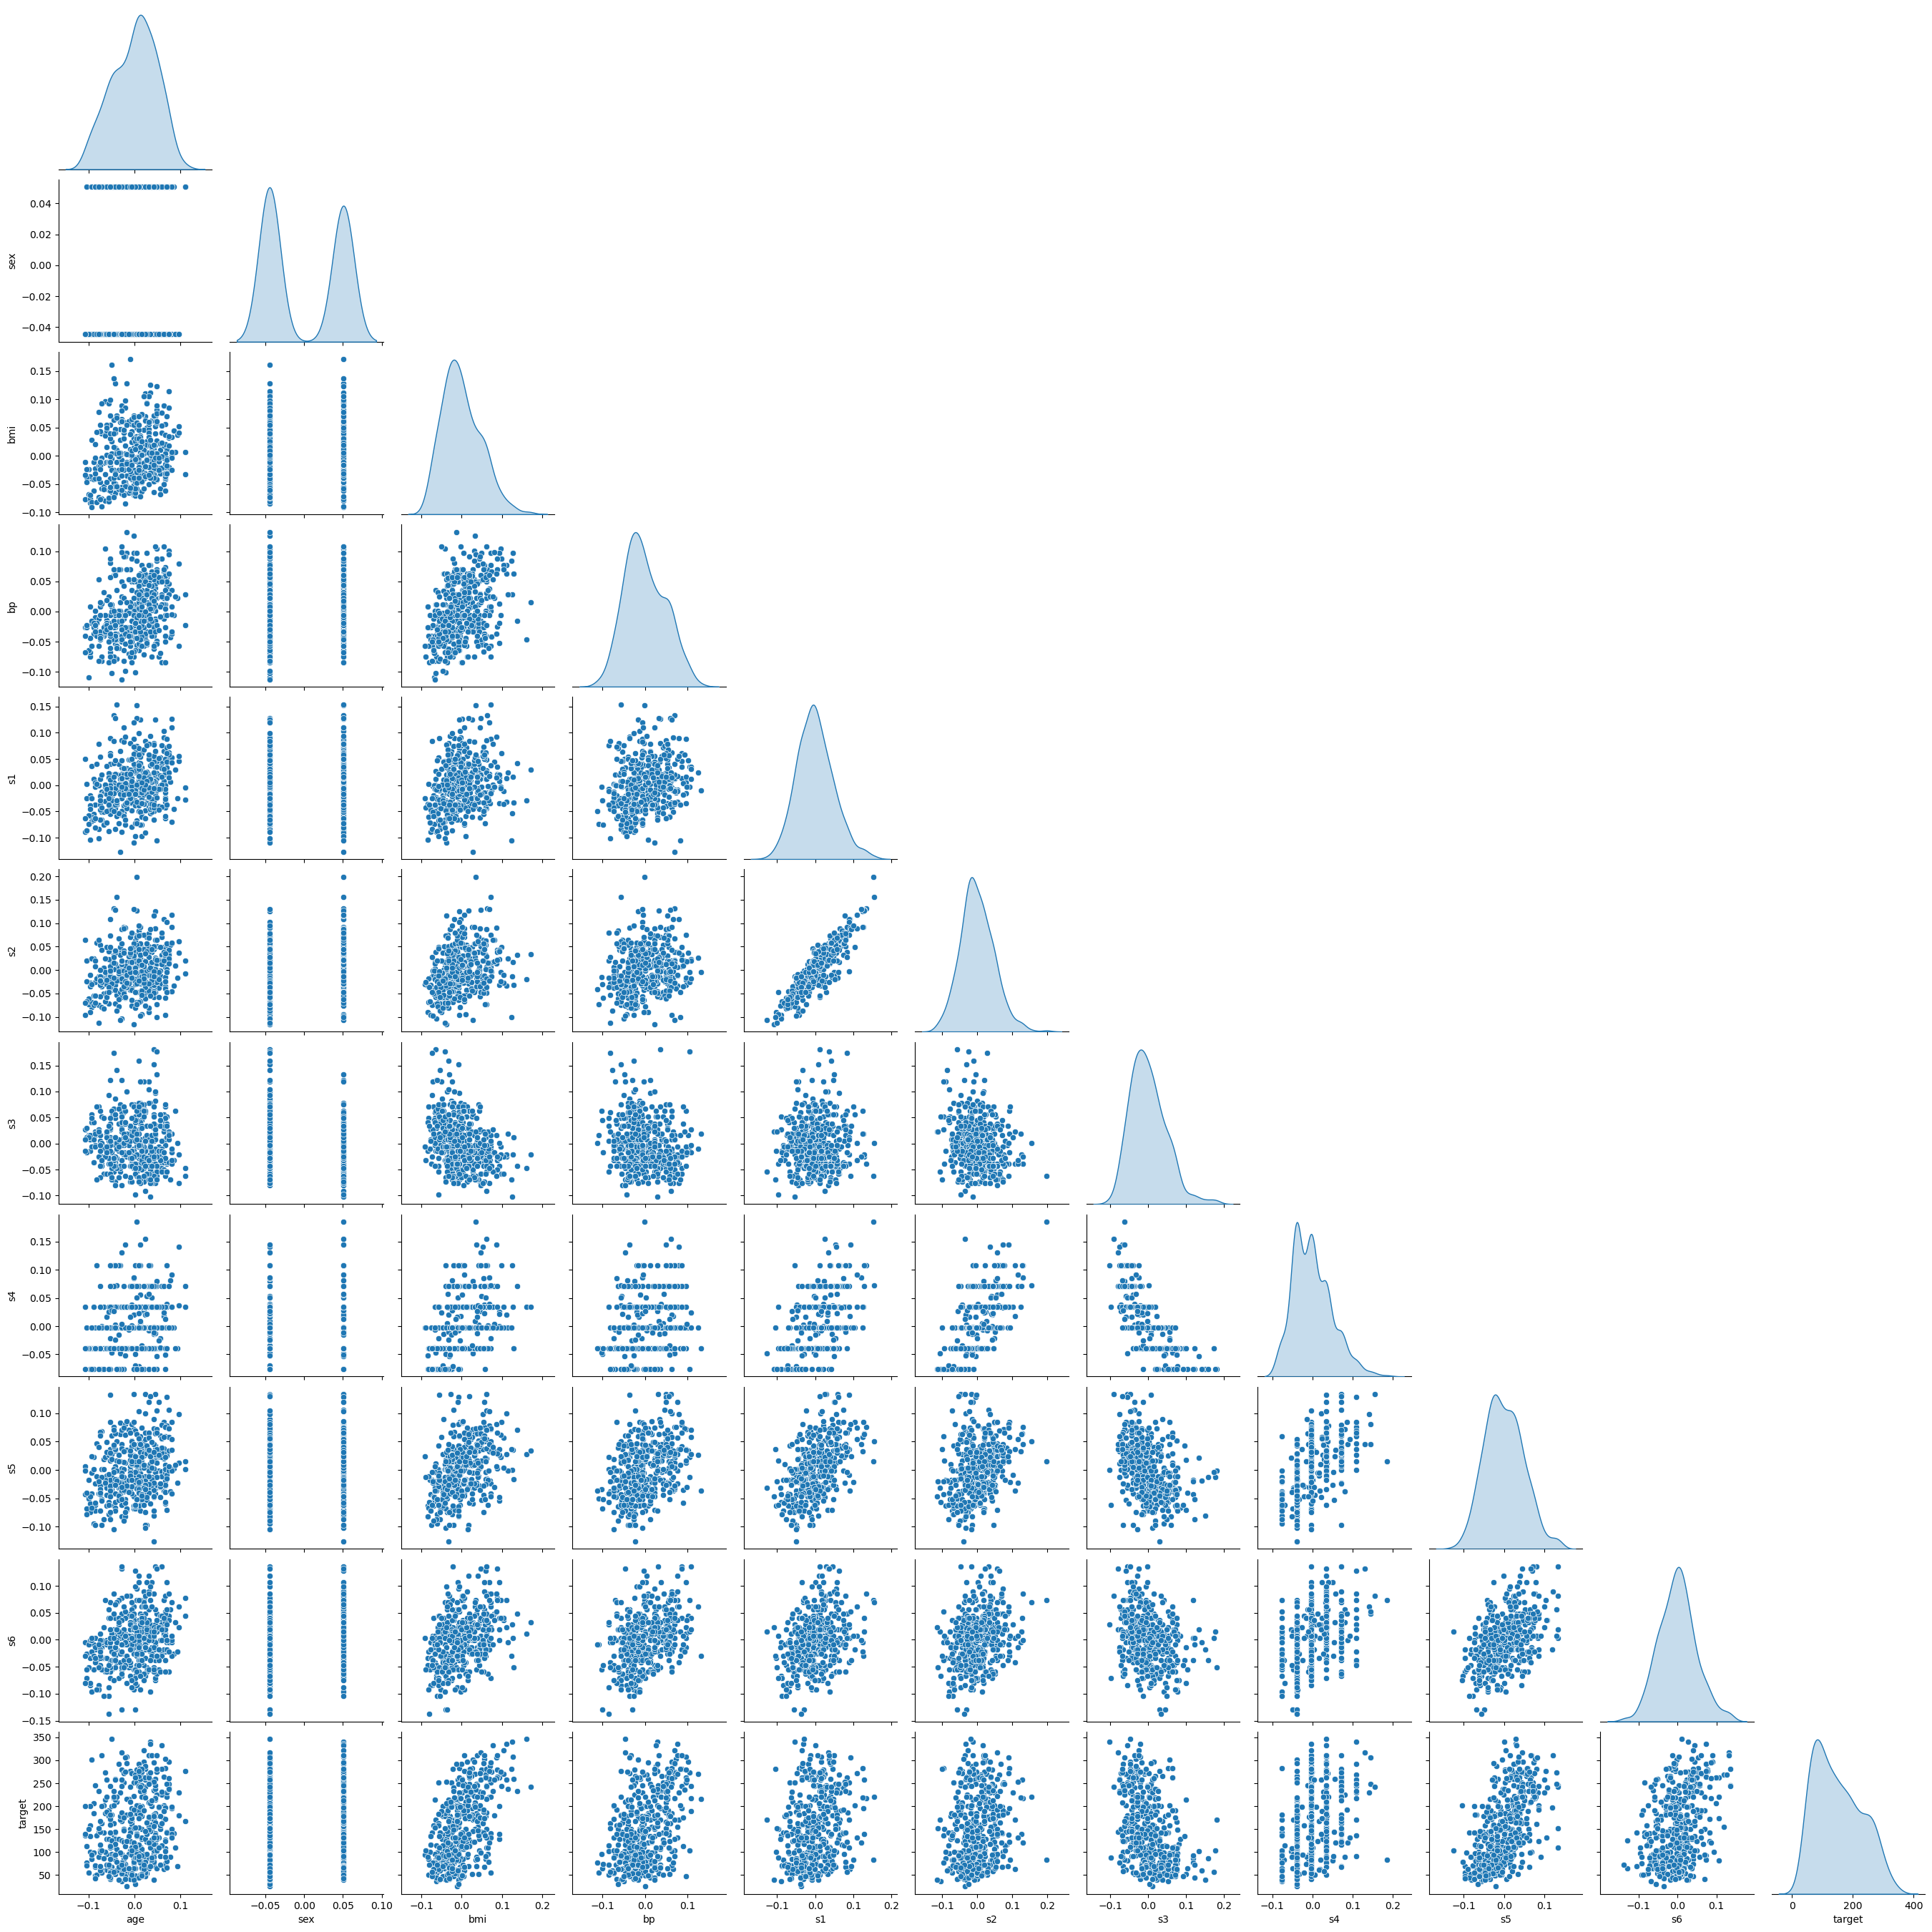

In [118]:
sns.pairplot(df,corner=True,diag_kind='kde')

In [119]:
df.keys()
print(f'check the preprocessing if the sum of squares are 1 for each column:  {np.sum(df.age**2)}')

check the preprocessing if the sum of squares are 1 for each column:  1.0000000000000009


{'whiskers': [<matplotlib.lines.Line2D at 0x714b16bc9670>,
 'caps': [<matplotlib.lines.Line2D at 0x714b16bcbb90>,
 'boxes': [<matplotlib.lines.Line2D at 0x714b16bc9ee0>],
 'medians': [<matplotlib.lines.Line2D at 0x714b22138200>],
 'fliers': [<matplotlib.lines.Line2D at 0x714b17a7eab0>],
 'means': []}

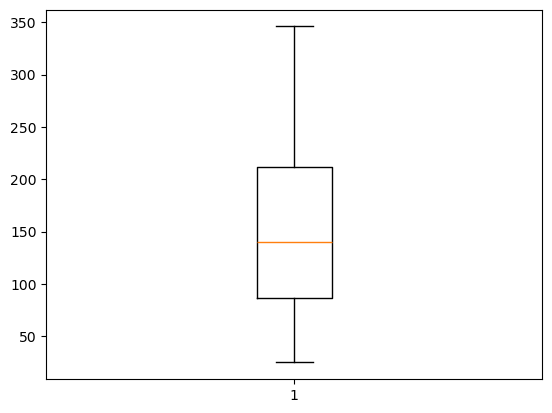

In [120]:
plt.boxplot(df["target"])

In [121]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Number of duplicate rows:
0


In [122]:
df.keys()

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [123]:
y = df['target']
X = df.drop('target', axis= 1) # axis = 1 for column axis 

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (331, 10)
X_test : (111, 10)
y_train: (331,)
y_test : (111,)


In [125]:
lr = LinearRegression().fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"Coefficients = {lr.coef_}")
print(f"Intercept = {lr.intercept_}")

print(f"Training set r2 score = {lr.score(X_train, y_train):.2f}")
print(f"Test set r2 score = {lr.score(X_test, y_test):.2f}")

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
pass

Coefficients = [ -43.26198867 -208.66589855  593.40654802  302.89100542 -560.19094014
  261.40753499   -8.86674758  135.93174293  703.18354112   28.34977176]
Intercept = 153.06786205925664
Training set r2 score = 0.56
Test set r2 score = 0.36
Mean Squared Error: 3180.16


# Multiple Linear Regression from scratch

Multiple linear regression is a model that captures the linear relationship between a dependent variable and multiple independent variables or features. Simple regression works when only one factor explains the outcome.
But in practice, outcomes are influenced by many variables.

- With 1 input → regression gives a line.
- With 2 inputs → regression gives a plane in 3D space.
- With n inputs → regression gives a hyperplane in n-dimensional space.


The general multiple linear regression model is:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_i x_i + \epsilon
$$

where:

- $\beta_0$ is the intercept.
- $\beta_0$ to $\beta_i$ are the regression coefficients.
- $x_1$ to $x_i$ are the features of the dataset.
- $\epsilon$ represents the residual or error term.

## Vector Representation

The multiple linear regression equation can also be represented using vector and matrix notation:

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}
$$

where:

$$
\mathbf{y}
=
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix},
\qquad
\mathbf{X}
=
\begin{bmatrix}
\mathbf{x}_0^{\mathsf{T}} \\
\mathbf{x}_1^{\mathsf{T}} \\
\vdots \\
\mathbf{x}_n^{\mathsf{T}}
\end{bmatrix},
$$

$$
\boldsymbol{\beta}
=
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_i
\end{bmatrix},
\qquad
\boldsymbol{\epsilon}
=
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\vdots \\
\epsilon_n
\end{bmatrix}.
$$

The vector $\mathbf{x}_0^{\mathsf{T}}$ contains a series of ones:

$$
\mathbf{x}_0^{\mathsf{T}} =
\begin{bmatrix}
1 & 1 & \cdots & 1
\end{bmatrix}.
$$

This column of ones allows the intercept term $\beta_0$ to be included in the matrix equation.

Using an estimate of the coefficient vector $\boldsymbol{\beta}$, the predicted output can be calculated as:

$$
\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}}.
$$


The $\beta$ values are estimated by minimizing the *Sum of Squred Residuals* (SSR):
$$
SSR(\beta) = \sum_{i}^{n}(y_i - \hat{y})^2 = \sum_{i}^{n}(y_i - \mathbf{X}\hat{\boldsymbol{\beta}})^2
$$


Cost Function: 
$$
J = \mathcal{L} (y_i, \hat{y}_i) \equiv SSR =  (Y - X\beta)^{T} (Y - X\beta)
$$

minimyzing the cost fucntion by partial differentiation w.r.t $\beta$ gives
$$
\beta = (X^T X)^{-1} X^T y  
$$

In [126]:
class MultipleLinearRegression():
        def __init__(self):
                self.coefficients = None
                self.intercept = None
        
        def fit(self, X, y):
                betas = self.calculate_coeff(X,y)
                self.intercept = betas[0]
                self.coefficients = betas[1:]
                
        def predict(self, X):
                y_pred = self.intercept + X @ self.coefficients
                return y_pred     
        
        def calculate_coeff(self, X, y):
                X = X.to_numpy()
                y = y.to_numpy()
                
                # add an identity column at the first in the X matrix 
                X = np.insert(X, 0, 1, axis=1)  
                
                betas = np.linalg.inv(X.T @ X) @ X.T @ y

                return betas  
        
        def r2_score(self, y_test, y_pred):
                ss_res = np.sum((y_test - y_pred) ** 2)
                ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

                r2 = 1 - (ss_res / ss_tot)

                return r2    
        
        def MSE(self, y_test, y_pred):
                return (np.mean((y_pred - y_test)**2))

In [165]:
X_test.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

In [127]:
mlr = MultipleLinearRegression()

mlr.fit(X_train, y_train)

# fit our LR to our data
mlr.fit(X_train, y_train)

#coeffs
coeff = mlr.calculate_coeff(X_train, y_train)
print(f"Slope: {coeff[1:]}, \n Intercept: {coeff[0]}")
# make predictions and score
y_pred = mlr.predict(X_test)

# calculate r2_score
r2score = mlr.r2_score(y_test, y_pred)
print(f'My Final R2 score: {r2score}')

# calculate MSE 
mse = mlr.MSE(y_test, y_pred)
print(f'My Final MSE score: {mse}')


Slope: [ -43.26198867 -208.66589855  593.40654802  302.89100542 -560.19094014
  261.40753499   -8.86674758  135.93174293  703.18354112   28.34977176], 
 Intercept: 153.06786205925664
My Final R2 score: 0.35940880381777085
My Final MSE score: 3180.1596481558445


In [145]:
print(X.columns.get_loc('s2'))


5


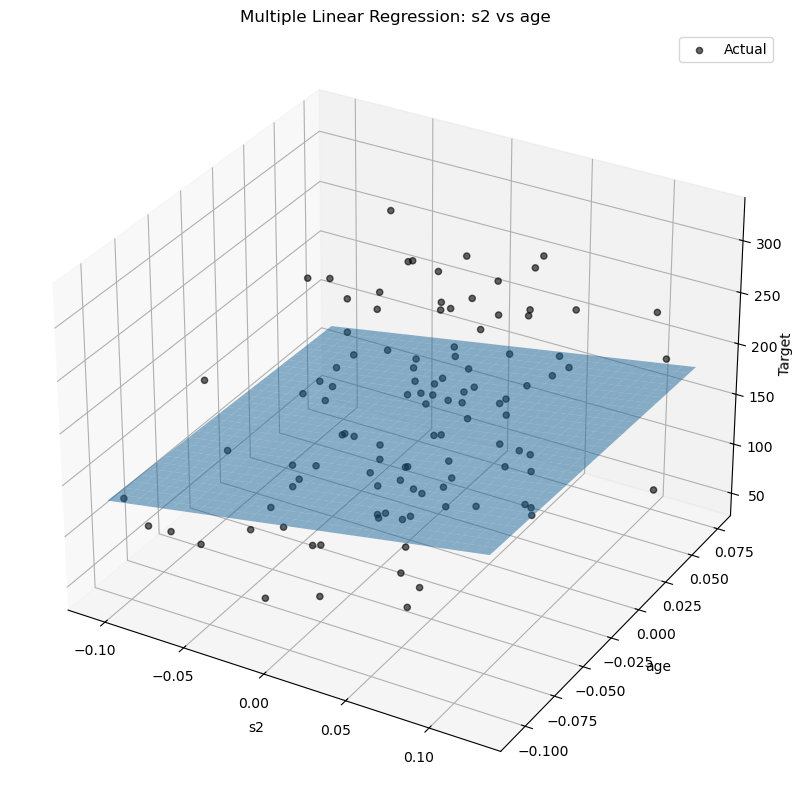

In [164]:
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------
# Select two features for visualization
# --------------------------------------------------

feature1 = 's2'
feature2 = 'age'

# Actual test data
x = X_test[feature1]
y = X_test[feature2]
z = y_test


# --------------------------------------------------
# Create grid for the regression surface
# --------------------------------------------------

x_pred = np.linspace(x.min(), x.max(), 30)
y_pred = np.linspace(y.min(), y.max(), 30)

X1, X2 = np.meshgrid(x_pred, y_pred)


# --------------------------------------------------
# Calculate predicted target using full model
# --------------------------------------------------

# Coefficients
b0   = coeff[0]    # intercept
b_age = coeff[1]   # age
b_s2  = coeff[6]   # s2

# Start with intercept + s2 + age
Z_pred = b0 + b_s2 * X1 + b_age * X2


# # --------------------------------------------------
# # Add contribution from remaining 8 features
# # --------------------------------------------------

# for i, feature in enumerate(X.columns):

#     if feature not in [feature1, feature2]:

#         # coefficient index = feature index + 1
#         beta = coeff[i + 1]

#         # Fix remaining feature at its training mean
#         Z_pred += beta * X_train[feature].mean()


# --------------------------------------------------
# 3D plot
# --------------------------------------------------

fig = plt.figure(figsize=(20, 10))

ax = fig.add_subplot(111, projection='3d')


# Actual test data
ax.scatter(x, y, z,color='black',alpha=0.6,label='Actual')


# Regression surface
ax.plot_surface(X1, X2, Z_pred,alpha=0.5)


# Labels
ax.set_xlabel('s2')
ax.set_ylabel('age')
ax.set_zlabel('Target', labelpad=0.3)
ax.set_title('Multiple Linear Regression: s2 vs age')
ax.legend()
plt.show()